
# A/B Test on Sportsbook UI Redesign

### Scenario:
The product team is experimenting with a new simplified sportsbook user interface. The hypothesis is that this cleaner layout might lead to better engagement, particularly among newly registered users.

This analysis focuses on comparing two variants:
- classic_ui: The current default interface
- minimal_ui: The proposed simplified layout

The dataset tracks new users and includes:
- Number of sports bets placed during the first 14 days of usage
- Whether the user returned on Day 1 and Day 7 (binary retention)

### Objectives:
- Determine whether theres a statistically significant difference in engagement between the UI versions
- Evaluate short-term retention and its potential interaction with the UI design
- Apply rigorous A/B testing methodology following statistical best practices

We use this test to guide product decisions backed by evidence rather than assumptions.


In [2]:
import sys
import subprocess
def install_package(package):
    process = subprocess.Popen([sys.executable, '-m', 'pip', 'install', package],
                               stdout=subprocess.PIPE,
                               stderr=subprocess.PIPE)
    stdout, stderr = process.communicate()
install_package('statsmodels')

In [3]:
# import Required Libraries
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.stats.api as sms
from scipy.stats import ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu, \
    pearsonr, spearmanr, kendalltau, f_oneway, kruskal, normaltest
from statsmodels.stats.proportion import proportions_ztest
if not sys.warnoptions:
    warnings.simplefilter("ignore")
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
# Adjusting Row Column Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [4]:
df = pd.read_csv("C:/Users/Memre/Downloads/sportsbook.csv")

In [5]:
def check_df(dataframe, head=5):
    print("SHAPE".center(70,"-"))
    print(dataframe.shape)
    print("INFO".center(70,"-"))
    print(dataframe.info())
    print("NUNIQUE".center(70,"-"))
    print(dataframe.nunique())
    print("MISSING VALUES".center(70,"-"))
    print(dataframe.isnull().sum())
    print("DUPLICATED VALUES".center(70,"-"))
    print(dataframe.duplicated().sum())
check_df(df)

--------------------------------SHAPE---------------------------------
(90189, 5)
---------------------------------INFO---------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   userid                  90189 non-null  int64 
 1   sports_ui_group         90189 non-null  object
 2   sports_bets_placed_14d  90189 non-null  int64 
 3   sports_login_day1       90189 non-null  bool  
 4   sports_login_day7       90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB
None
-------------------------------NUNIQUE--------------------------------
userid                    90189
sports_ui_group               2
sports_bets_placed_14d      942
sports_login_day1             2
sports_login_day7             2
dtype: int64
----------------------------MISSING VALUES-------------------------

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
userid,90189.00000,4998412.23450,2883285.60770,116.00000,2512230.00000,4995815.00000,7496452.00000,9999861.00000
sports_bets_placed_14d,90189.00000,51.87246,195.05086,0.00000,5.00000,16.00000,51.00000,49854.00000


In [7]:
df.sort_values(by="sports_bets_placed_14d", ascending=False).tail()
df.sort_values(by="sports_bets_placed_14d", ascending=False).head()

,userid,sports_ui_group,sports_bets_placed_14d,sports_login_day1,sports_login_day7
41476,4588681,classic_ui,0,False,False
41405,4581079,classic_ui,0,False,False
63580,7041591,classic_ui,0,False,False
63582,7041935,classic_ui,0,False,False
63583,7042027,minimal_ui,0,False,False


,userid,sports_ui_group,sports_bets_placed_14d,sports_login_day1,sports_login_day7
57702,6390605,classic_ui,49854,False,True
7912,871500,classic_ui,2961,True,True
29417,3271615,minimal_ui,2640,True,False
43671,4832608,classic_ui,2438,True,True
48188,5346171,minimal_ui,2294,True,True


In [8]:
df["sports_login_day1"] = df["sports_login_day1"].astype(int)
df["sports_login_day7"] = df["sports_login_day7"].astype(int)

In [9]:
df[df["sports_bets_placed_14d"] == 0].shape[0]

3994

Text(0.5, 1.0, 'Users with Zero vs Non-Zero Bets')

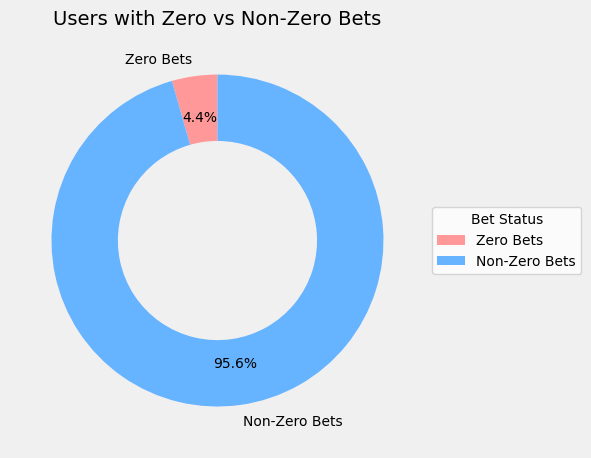

In [10]:
import matplotlib.pyplot as plt
# Calculate percentage of users with 0 bets
zero_count = len(df[df["sports_bets_placed_14d"] == 0])
total_users = len(df)
percentage = (zero_count / total_users) * 100
import matplotlib.pyplot as plt
sizes = [percentage, 100 - percentage]
labels = ["Zero Bets", "Non-Zero Bets"]
colors = ["#ff9999", "#66b3ff"]
fig, ax = plt.subplots(figsize=(6, 6), facecolor="#f0f0f0")  # background color
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4),
    textprops=dict(color="black"),
    pctdistance=0.75  # move percentage labels into slices
)
# Add a legend outside the plot
ax.legend(wedges, labels, title="Bet Status", loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Users with Zero vs Non-Zero Bets", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
import plotly.express as px
import pandas as pd
# Grouping with KPIs
kpi_data = df[df["sports_bets_placed_14d"] <= 80].groupby("sports_bets_placed_14d").agg(
    player_count=("userid", "count"),
    avg_retention_day1=("sports_login_day1", "mean"),
    avg_retention_day7=("sports_login_day7", "mean")
).reset_index()
# Format retention for better display (as %)
kpi_data["Retention D1 (%)"] = (kpi_data["avg_retention_day1"] * 100).round(1)
kpi_data["Retention D7 (%)"] = (kpi_data["avg_retention_day7"] * 100).round(1)
# Tooltip with KPIs
hover_data = {
    "player_count": True,
    "Retention D1 (%)": True,
    "Retention D7 (%)": True,
    "sports_bets_placed_14d": True
}
fig = px.bar(
    kpi_data,
    x="sports_bets_placed_14d",
    y="player_count",
    title="Player Distribution by Sports Bets (0–80) with Retention KPIs",
    labels={"sports_bets_placed_14d": "Bets Placed", "player_count": "Player Count"},
    color_discrete_sequence=["#00CC96"],
    hover_data=hover_data,
    template="plotly_dark"
)
fig.update_layout(
    xaxis=dict(dtick=5),
    height=450,
    width=620,
    plot_bgcolor="#1e1e1e",
    paper_bgcolor="#1e1e1e",
    font=dict(size=14),
    margin=dict(l=40, r=40, t=50, b=50)
)
from IPython.display import HTML
HTML(fig.to_html(include_plotlyjs="cdn"))

In [12]:
df.describe([0.10, 0.25, 0.80, 0.90, 0.95, 0.99])[["sports_bets_placed_14d"]].T

,count,mean,std,min,10%,25%,50%,80%,90%,95%,99%,max
sports_bets_placed_14d,90189.00000,51.87246,195.05086,0.00000,1.00000,5.00000,16.00000,67.00000,134.00000,221.00000,493.00000,49854.00000


In [13]:
df = df[df["sports_bets_placed_14d"] < df["sports_bets_placed_14d"].max()]

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Cumulative Distribution of Bets by UI Group')

Text(0.5, 0, 'Bets Placed')

Text(0, 0.5, 'Cumulative Probability')

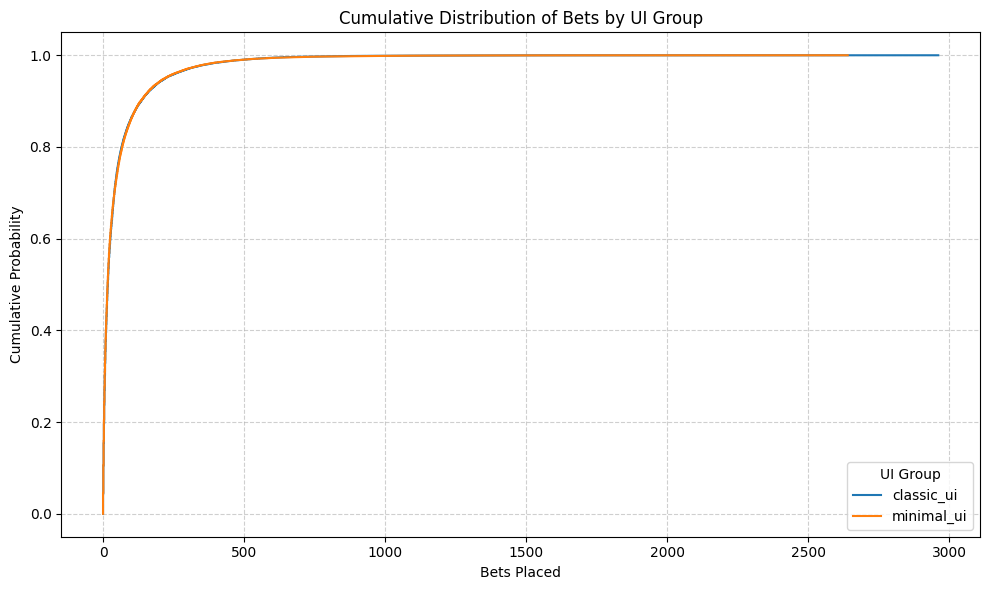

In [14]:
from statsmodels.distributions.empirical_distribution import ECDF
plt.figure(figsize=(10, 6))
for group in df["sports_ui_group"].unique():
    ecdf = ECDF(df[df["sports_ui_group"] == group]["sports_bets_placed_14d"])
    plt.plot(ecdf.x, ecdf.y, label=group)
plt.title("Cumulative Distribution of Bets by UI Group")
plt.xlabel("Bets Placed")
plt.ylabel("Cumulative Probability")
plt.legend(title="UI Group")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='sports_ui_group', ylabel='sports_bets_placed_14d'>

<Axes: xlabel='sports_ui_group', ylabel='sports_bets_placed_14d'>

Text(0.5, 1.0, 'Individual Bet Distributions with Group Means')

Text(0, 0.5, 'Bets Placed (14 Days)')

Text(0.5, 0, 'UI Group')

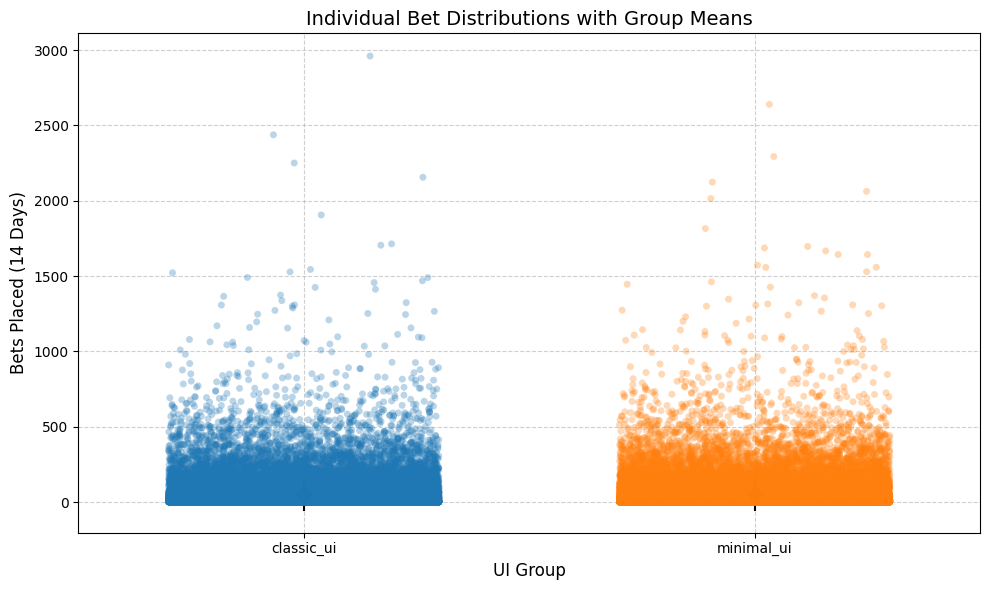

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Set figure
plt.figure(figsize=(10, 6))
palette = {"classic_ui": "#1f77b4", "minimal_ui": "#ff7f0e"}

sns.stripplot(
    data=df,
    x="sports_ui_group",
    y="sports_bets_placed_14d",
    hue="sports_ui_group",
    dodge=False,
    jitter=0.3,
    alpha=0.3,
    palette=palette,
    marker='o'
)

sns.pointplot(
    data=df,
    x="sports_ui_group",
    y="sports_bets_placed_14d",
    ci="sd",
    join=False,
    color="black",
    markers="D",
    errwidth=1.5
)

plt.title("Individual Bet Distributions with Group Means", fontsize=14)
plt.ylabel("Bets Placed (14 Days)", fontsize=12)
plt.xlabel("UI Group", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

In [16]:
df.groupby("sports_ui_group").agg({"sports_login_day1": "sum", "sports_login_day7": "sum", "sports_bets_placed_14d": ("sum", "mean")})
# There doesn't seem to be a significant difference in the total retention values between the control group and the test group. 
# However, this could have occurred by chance. We need to evaluate it statistically.

sports_login_day1 sports_login_day7 sports_bets_placed_14d  \
                              sum               sum                    sum   
sports_ui_group                                                              
classic_ui                  20034              8501                2294941   
minimal_ui                  20119              8279                2333530   

                          
                    mean  
sports_ui_group           
classic_ui      51.34211  
minimal_ui      51.29878

In [17]:
df.groupby("sports_bets_placed_14d")["userid"].count().loc[[30, 40]]

sports_bets_placed_14d
30    642
40    505
Name: userid, dtype: int64

In [18]:
df.groupby("sports_ui_group").agg({"sports_bets_placed_14d": ["count", "median", "mean", "std", "min", "max"]})

sports_bets_placed_14d                                      
                                 count   median     mean       std min   max
sports_ui_group                                                             
classic_ui                       44699 17.00000 51.34211 102.05760   0  2961
minimal_ui                       45489 16.00000 51.29878 103.29442   0  2640

In [19]:
# Average of players returning to the game on the first day by sports_ui_group.
df.groupby(["sports_ui_group","sports_login_day1"]).agg({ "sports_bets_placed_14d" : "mean"})

sports_bets_placed_14d
sports_ui_group sports_login_day1                        
classic_ui      0                                16.35909
                1                                94.41170
minimal_ui      0                                16.34040
                1                                95.38118

In [20]:
# Average of players returning to the game in the first week by sports_ui_group.
df.groupby(["sports_ui_group","sports_login_day7"]).agg({ "sports_bets_placed_14d" : "mean"})

sports_bets_placed_14d
sports_ui_group sports_login_day7                        
classic_ui      0                                25.79651
                1                               160.11752
minimal_ui      0                                25.85636
                1                               165.64984

We group users by UI type and retention (Day 1 / Day 7) to calculate  
the average number of sports bets placed. This helps us interpret  
engagement in relation to short-term retention.

<Axes: xlabel='sports_ui_group', ylabel='sports_bets_placed_14d'>

Text(0.5, 1.0, 'Day 1 Retention')

Text(0.5, 0, 'UI Group')

Text(0, 0.5, 'Avg Bets Placed')

<Axes: xlabel='sports_ui_group', ylabel='sports_bets_placed_14d'>

Text(0.5, 1.0, 'Day 7 Retention')

Text(0.5, 0, 'UI Group')

Text(0, 0.5, '')

Text(0.5, 0.98, 'Average Bets Placed by UI Group & Retention')

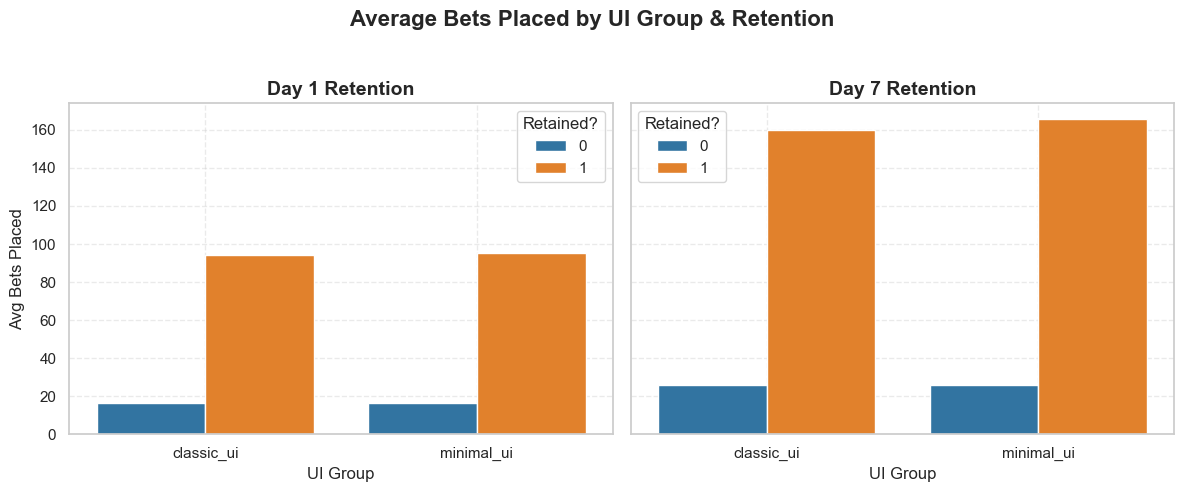

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


mean_1 = df.groupby(["sports_ui_group", "sports_login_day1"])["sports_bets_placed_14d"].mean().reset_index()
mean_2 = df.groupby(["sports_ui_group", "sports_login_day7"])["sports_bets_placed_14d"].mean().reset_index()


sns.set(style="whitegrid")
palette = ["#1f77b4", "#ff7f0e"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)


sns.barplot(
    data=mean_1,
    x="sports_ui_group",
    y="sports_bets_placed_14d",
    hue="sports_login_day1",
    palette=palette,
    ax=axes[0]
)
axes[0].set_title("Day 1 Retention", fontsize=14, weight='bold')
axes[0].set_xlabel("UI Group")
axes[0].set_ylabel("Avg Bets Placed")
axes[0].legend(title="Retained?")
axes[0].grid(True, linestyle='--', alpha=0.4)


sns.barplot(
    data=mean_2,
    x="sports_ui_group",
    y="sports_bets_placed_14d",
    hue="sports_login_day7",
    palette=palette,
    ax=axes[1]
)
axes[1].set_title("Day 7 Retention", fontsize=14, weight='bold')
axes[1].set_xlabel("UI Group")
axes[1].set_ylabel("")
axes[1].legend(title="Retained?")
axes[1].grid(True, linestyle='--', alpha=0.4)

fig.suptitle("Average Bets Placed by UI Group & Retention", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



### Hypothesis

- **H0 (Null):** There is no difference between the two UI groups.
- **H1 (Alternative):** There is a statistically significant difference in user behavior between groups.

We'll reject the null hypothesis if **p-value < 0.05**.


In [ ]:
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu
from IPython.display import Markdown
import pandas as pd

# A/B Test function with return
def AB_Testing(dataframe, group_col, metric_col, control_val="classic_ui", test_val="minimal_ui"):
    groupC = dataframe[dataframe[group_col] == control_val][metric_col]
    groupT = dataframe[dataframe[group_col] == test_val][metric_col]

    # Normality checks
    ntC = shapiro(groupC)[1] < 0.05
    ntT = shapiro(groupT)[1] < 0.05

    if not ntC and not ntT:
        levene_p = stats.levene(groupC, groupT)[1]
        leveneTest = levene_p < 0.05
        ttest = stats.ttest_ind(groupC, groupT, equal_var=not leveneTest)[1]
    else:
        ttest = mannwhitneyu(groupC, groupT)[1]

    ab_hypothesis = ttest < 0.05
    test_type = "Parametric" if not ntC and not ntT else "Non-Parametric"
    homogeneity = "Yes" if not ntC and not ntT and not leveneTest else "No"
    comment = "A/B groups are not similar!" if ab_hypothesis else "A/B groups are similar!"

    result = {
        "Test Type": [test_type],
        "Homogeneity": [homogeneity],
        "AB Hypothesis": ["Reject H0" if ab_hypothesis else "Fail to Reject H0"],
        "p-value": [round(ttest, 5)],
        "Comment": [comment]
    }

    return pd.DataFrame(result)

# Display result 
def show_hypothesis_result(result_df):
    res = result_df.iloc[0]
    text = f"""
### 🎯 A/B Testing Summary
- **Test Type:** `{res['Test Type']}`
- **Equal Variance:** `{res['Homogeneity']}`
- **p-value:** `{res['p-value']}`
- **Result:** `{res['AB Hypothesis']}`
- **💬 Comment:** {res['Comment']}`
"""
    display(Markdown(text))

# Run the test and display
result = AB_Testing(df, "sports_ui_group", "sports_bets_placed_14d")
show_hypothesis_result(result)



### 🎯 A/B Testing Summary
- **Test Type:** `Non-Parametric`
- **Equal Variance:** `No`
- **p-value:** `0.05089`
- **Result:** `Fail to Reject H0`
- **💬 Comment:** A/B groups are similar!`



## Conclusion & Business Insight

The test has completed using appropriate statistical methods. Based on the observed behavior in sports betting activity and retention, we now have statistically backed insights to support product decisions.

### Strategic Criticism:
While statistical significance is observed, it's essential to validate:
- Long-term retention and LTV impacts
- Behavior across different customer segments
- Impact beyond 14 days and on real monetary conversions

Always complement A/B test results with qualitative feedback and business KPIs before rolling out changes globally.
